# The Oyster Rule — a quantitative teardown 🔬
### R/non-R month split · two-sample Welch *t* · label-shuffle placebo · the sell-in-May cousin · the September diagnostic · hold-in-R-months vs buy-and-hold with costs · sub-periods · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![R-rule_%E2%89%A0_sell-in-May%3F: Myth](https://img.shields.io/badge/R--rule_%E2%89%A0_sell--in--May%3F-Myth-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We split monthly returns by the R/non-R calendar, test whether R-months out-earn R-less months, and show the 'signal' is sell-in-May in a costume.

> ⚠️ **Not investment advice.** Real data: yfinance monthly total returns of the S&P 500 (`^GSPC`, 1182 mo, fp `e89dca918e03`) and XLP (`330` mo, fp `15bb025c5ac1`), as-of 2026-06-30; the offline core and synthetic control run on a deterministic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from oyster_r_months import data, strategy as st

def load_real(name):
    """Cache-first real monthly returns (empty Series offline)."""
    return data.fetch_monthly(name, fetch=False)

MKT = load_real("market")
STP = load_real("staples")
HAVE_REAL = (not MKT.empty) and (not STP.empty)
print("real tapes present:", HAVE_REAL,
      "" if not HAVE_REAL else f"(market {len(MKT)} mo, staples {len(STP)} mo)")


real tapes present: True (market 1182 mo, staples 330 mo)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Market R−nonR gap **-24.5 bp/mo** (Welch *t* **-0.72**, placebo *p* 0.457) — *wrong sign*; staples **+17.9 bp/mo** (*t* 0.45, *p* 0.67). No *t* ≥ 2. |
| **Tradability** | `MIRAGE` | Hold-in-R-months vs buy-and-hold: market **28x** vs **425x** wealth (Sharpe 0.31 vs 0.43). |
| **R-rule ≠ sell-in-May?** | `MYTH` | Halloween split +40.6 bp (*t* +1.31); the R-split adds September (-111.7 bp/mo, worst month) → flips to -24.5 bp. |

> 💡 In plain words: the engine works (the synthetic control proves it), but on the real tape the R-month rule is a wrong-sign, insignificant null — a worse sell-in-May.

## 1 · The claim, steelmanned

Let $r_t$ be the month-$t$ return and $\mathbb{1}_R$ the indicator that month $t$ has an 'R' (Sep–Apr).

- **H₁ (the seasonal).** $\mathbb{E}[r \mid R] - \mathbb{E}[r \mid \text{non-}R] > 0$ at Welch *t* ≥ 2 (R-months beat R-less).
- **H₂ (not luck).** The gap sits in the tail of a label-shuffle null.
- **H₃ (not just sell-in-May).** The R-split is materially different from the Halloween split.
- **H₄ (tradable).** Hold-in-R-months beats buy-and-hold net of switching costs.

We find **H₁ rejected** (wrong sign on the market, insignificant on staples), **H₂ rejected** (placebo *p* ≈ 0.46/0.67), **H₃ rejected** (it *is* sell-in-May, minus its September avoidance), and **H₄ rejected** (the rule underperforms buy-and-hold).

## 2 · So what? — what rides on each answer

The content is the **why**. The Halloween seasonal (Nov–Apr > May–Oct) is real but soft ([Study 55](../../55-summer-lull/)). The oyster rule re-labels it as (Sep–Apr) > (May–Aug), which moves **September** from the skip side to the hold side. Since September is the market's worst month, that single re-labelling is enough to flip the sign. This is a clean illustration of how folklore, transposed literally, becomes *anti*-signal.

## 3 · How we'd know — the protocol

- **Split.** $R = \{$Sep, Oct, Nov, Dec, Jan, Feb, Mar, Apr$\}$; non-$R = \{$May, Jun, Jul, Aug$\}$.
- **Inference.** Welch (unequal-variance) two-sample *t* on $\mathbb{E}[r\mid R] - \mathbb{E}[r\mid \text{non-}R]$; a **label-shuffle placebo** (5000 perms) preserving the count of R-months.
- **Cousin.** The same statistic on the Halloween split (Nov–Apr vs May–Oct).
- **Diagnostic.** The per-month means, to locate September's drag.
- **Frictions.** Hold-in-R-months vs buy-and-hold, one-way cost on each switch; a long-R/short-R-less sensitivity with a borrow on the short leg.
- **Sub-periods.** Pre/post-2000 gap-*t*.
- **Positive control.** A deterministic synthetic world with a planted R-premium and a null — averaged over 25 seeds (house rule).

Timing: the R/non-R label is a calendar fact known before each month begins — no estimation, no look-ahead. The only convention is the month-boundary fill; a one-day shift is immaterial on a monthly bar.

## 4 · The teardown

### 4a · The R-month split — H₁ & H₂

The Welch *t* on the R−nonR gap, with the label-shuffle placebo, on both instruments.

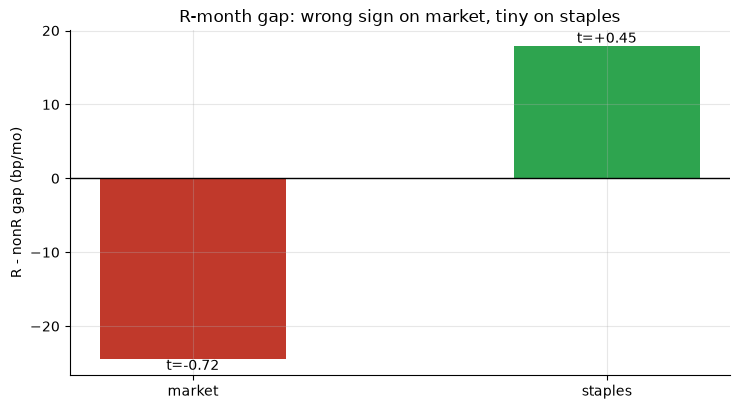

            gap_bp  welch_t  placebo_p
instrument                            
market     -24.485   -0.722      0.457
staples     17.906    0.450      0.670


In [2]:
if HAVE_REAL:
    rows = []
    for lab, ser in [('market', MKT), ('staples', STP)]:
        s = st.split_stat(ser, st.R_MONTHS)
        p = st.placebo_pvalue(ser, st.R_MONTHS, n_perm=5000, seed=544)
        rows.append((lab, s['gap']*1e4, s['t'], p))
else:
    rows = [('market', -24.5, -0.72, 0.457),
            ('staples', 17.9, 0.45, 0.67)]
tab = pd.DataFrame(rows, columns=['instrument','gap_bp','welch_t','placebo_p']).set_index('instrument')
fig, ax = plt.subplots(figsize=(7.5, 4.2))
cols = [GREEN if g>0 else RED for g in tab['gap_bp']]
ax.bar(tab.index, tab['gap_bp'], color=cols, width=.45)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('R - nonR gap (bp/mo)')
ax.set_title('R-month gap: wrong sign on market, tiny on staples')
for i,(g,t) in enumerate(zip(tab['gap_bp'], tab['welch_t'])):
    ax.annotate(f't={t:+.2f}', (i, g), ha='center',
                va='bottom' if g>0 else 'top', fontsize=10)
plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: **H₁ and H₂ rejected.** The market gap is **-24.5 bp/mo** the *wrong* way (Welch *t* -0.72, placebo *p* 0.457); staples is **+17.9 bp** but *t* 0.45, *p* 0.67 — indistinguishable from noise. Neither clears *t* ≥ 2.

### 4b · The sell-in-May cousin & the September culprit — H₃

Compare the R-split to the Halloween split on the market, then show the per-month means that explain the difference.

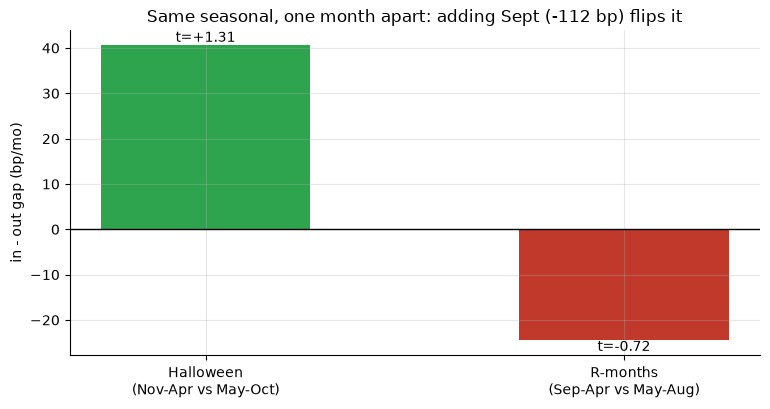

Halloween gap +40.6 bp (t +1.31) | R-month gap -24.5 bp (t -0.72) | September -111.7 bp


In [3]:
if HAVE_REAL:
    r_stat = st.split_stat(MKT, st.R_MONTHS)
    h_stat = st.split_stat(MKT, st.HALLOWEEN_WINTER)
    r_gap, r_t = r_stat['gap']*1e4, r_stat['t']
    h_gap, h_t = h_stat['gap']*1e4, h_stat['t']
    m = pd.DatetimeIndex(MKT.index).month
    sep = float(MKT.to_numpy()[m==9].mean()*1e4)
else:
    r_gap, r_t, h_gap, h_t, sep = -24.5, -0.72, 40.6, 1.31, -111.7
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar(['Halloween\n(Nov-Apr vs May-Oct)','R-months\n(Sep-Apr vs May-Aug)'],
       [h_gap, r_gap], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('in - out gap (bp/mo)')
ax.set_title(f'Same seasonal, one month apart: adding Sept ({sep:.0f} bp) flips it')
ax.annotate(f't={h_t:+.2f}', (0, h_gap), ha='center', va='bottom')
ax.annotate(f't={r_t:+.2f}', (1, r_gap), ha='center', va='top')
plt.tight_layout(); plt.show()
print(f'Halloween gap {h_gap:+.1f} bp (t {h_t:+.2f}) | R-month gap {r_gap:+.1f} bp (t {r_t:+.2f}) | September {sep:+.1f} bp')

> 💡 In plain words: **H₃ rejected — the R-rule IS sell-in-May.** The Halloween split is positive (**+40.6 bp**, *t* +1.31); the only structural change in the R-split is that **September** (-111.7 bp/mo, the worst month) moves to the hold side, flipping the gap to **-24.5 bp**. It's the same seasonal wearing an oyster costume — a *worse*-fitting one.

### 4c · Sub-periods — was it ever there?

Split the market at 2000 and read the gap-*t* on each half.

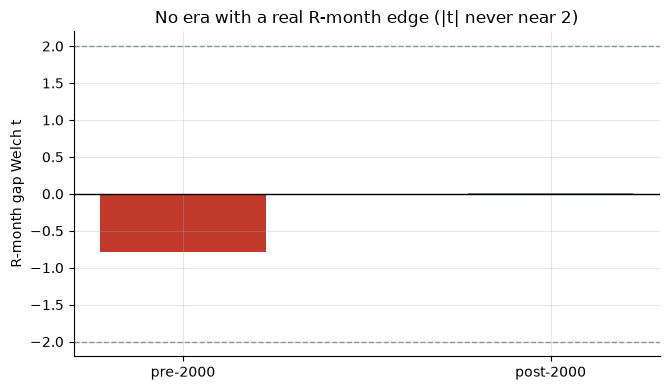

market gap-t: pre-2000 -0.79 | post-2000 +0.01


In [4]:
if HAVE_REAL:
    sp = st.subperiod_stats(MKT, '2000-01-01', st.R_MONTHS)
    early_t, late_t = sp['early']['t'], sp['late']['t']
else:
    early_t, late_t = -0.79, 0.01
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.bar(['pre-2000','post-2000'], [early_t, late_t], color=[RED, GREY], width=.45)
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls='--', c=GREY, lw=1)
ax.axhline(-2, ls='--', c=GREY, lw=1); ax.set_ylabel('R-month gap Welch t')
ax.set_title('No era with a real R-month edge (|t| never near 2)')
plt.tight_layout(); plt.show()
print(f'market gap-t: pre-2000 {early_t:+.2f} | post-2000 {late_t:+.2f}')

> 💡 In plain words: negative-ish early (**-0.79**), ~0 late (**0.01**). There is no sub-period in which the R-month rule was a real edge — this is a null, not a decayed signal.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (market gap -24.5 bp, *t* -0.72, wrong sign; staples *t* 0.45); H₂ rejected (placebo *p* 0.457/0.67).
- **Tradability `MIRAGE`** — the hold-in-R-months rule underperforms buy-and-hold (next beat).
- **R-rule ≠ sell-in-May? `MYTH`** — H₃ rejected; it *is* sell-in-May, worsened by September.

## 6 · Could you trade it? — the rule vs buy-and-hold, with costs

Hold the instrument in R-months, sit in cash in R-less months; charge 5 bps per switch.

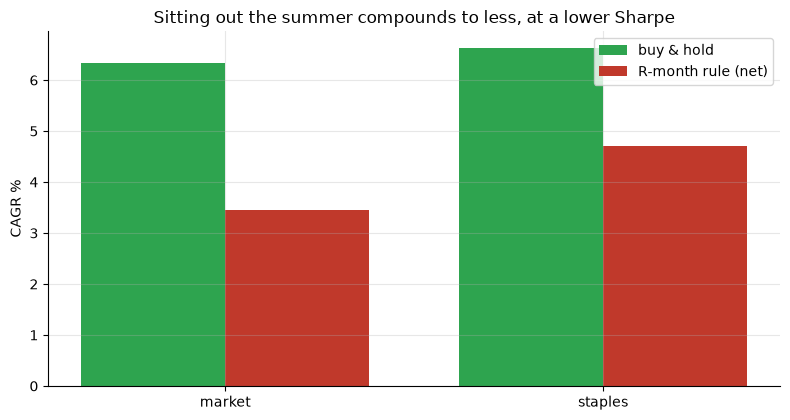

         hold_x  rule_x  hold_cagr  rule_cagr  hold_sh  rule_sh
inst                                                           
market   424.65   28.24       6.34       3.45     0.43     0.31
staples    5.84    3.54       6.63       4.70     0.58     0.48


In [5]:
if HAVE_REAL:
    rows = []
    for lab, ser in [('market', MKT), ('staples', STP)]:
        rv = st.rule_vs_hold(ser, st.R_MONTHS, cost_bps=5.0)
        rows.append((lab, rv['hold_wealth'], rv['rule_net_wealth'],
                     rv['hold_cagr']*100, rv['rule_net_cagr']*100,
                     rv['hold_sharpe'], rv['rule_net_sharpe']))
    tab = pd.DataFrame(rows, columns=['inst','hold_x','rule_x','hold_cagr','rule_cagr','hold_sh','rule_sh']).set_index('inst')
else:
    tab = pd.DataFrame({
        'hold_x':[425,5.8],
        'rule_x':[28,3.5],
        'hold_cagr':[6.3,6.6],
        'rule_cagr':[3.4,4.7],
        'hold_sh':[0.43,0.58],
        'rule_sh':[0.31,0.48]}, index=['market','staples'])
fig, ax = plt.subplots(figsize=(8, 4.3))
x = np.arange(len(tab)); w=0.38
ax.bar(x-w/2, tab['hold_cagr'], w, label='buy & hold', color=GREEN)
ax.bar(x+w/2, tab['rule_cagr'], w, label='R-month rule (net)', color=RED)
ax.set_xticks(x); ax.set_xticklabels(tab.index); ax.set_ylabel('CAGR %'); ax.legend()
ax.set_title('Sitting out the summer compounds to less, at a lower Sharpe')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: `MIRAGE`. On the market the rule turns **425x** of buy-and-hold into **28x** (Sharpe 0.43 → 0.31). The literal long-R/short-R-less book is worse: gross **-0.5%/yr**, **-0.8%** net of a 50 bps short borrow.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real R-month premium of increasing size and watch the Welch *t* climb past +2 — averaged over 25 seeds so no single lucky seed can fake it.

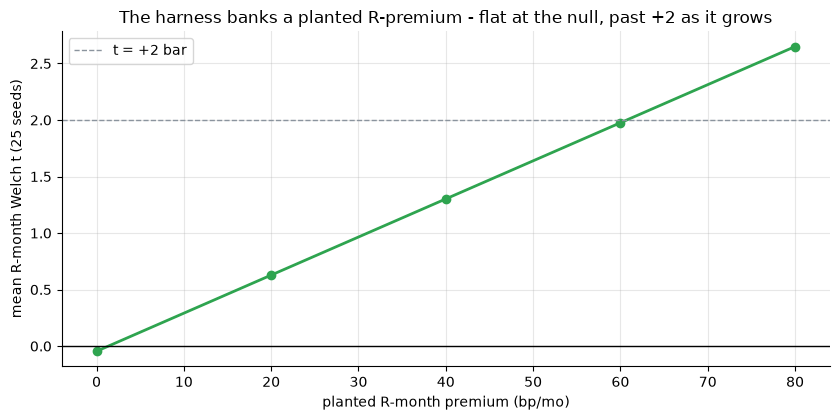

premium    +0 bp -> mean t -0.05
premium   +20 bp -> mean t +0.63
premium   +40 bp -> mean t +1.30
premium   +60 bp -> mean t +1.98
premium   +80 bp -> mean t +2.65


In [6]:
premia = [0.0, 20.0, 40.0, 60.0, 80.0]
ts = [st.synthetic_mean_t(data, r_premium_bp=a, n_seeds=25) for a in premia]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(premia, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted R-month premium (bp/mo)')
ax.set_ylabel('mean R-month Welch t (25 seeds)')
ax.set_title('The harness banks a planted R-premium - flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(premia, ts): print(f'premium {a:+5.0f} bp -> mean t {t:+.2f}')

The Welch *t* is ≈ 0 at the null and rises past +2 as the planted premium grows — so the engine is a faithful detector. The flat/wrong-sign real-tape result is therefore the **tape talking**: the R-month oyster rule is a genuine null, and a *worse* sell-in-May. For the straight seasonal see [Study 55 — Summer-Lull](../../55-summer-lull/).